# II. Likelihood and Estimation

- Specify a statistical model (e.g., Bernoulli, Normal, Logistic)
- Write down the likelihood function (conceptually or mathematically)
- Compute or estimate parameters using MLE
- Visualize or interpret how the likelihood behaves
  
**Inferential Question:** Is there a credible difference between the mean GPA of scholarship students and non-scholarship students in the wider student population?

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Load Data

data = pd.read_csv("../data/prepared_student_data.csv")

In [12]:
data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


In [13]:
# Separate scholarship and non-scholarship students
non_scholarship = data[data['scholarship_yes'] == 0]["cumulative_gpa"]
scholarship = data[data['scholarship_yes'] == 1]["cumulative_gpa"]

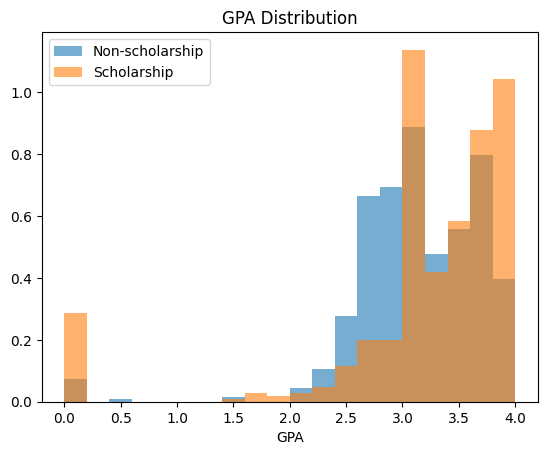

In [14]:
# Visualize gpa distributions

plt.figure()
plt.hist(non_scholarship, bins=20, alpha=0.6, density=True, label="Non-scholarship")
plt.hist(scholarship, bins=20, alpha=0.6, density=True, label="Scholarship")
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.legend()
plt.show()

### Specify a statistical model

Statistical Model: **Normal Distribution**

The distribution of GPA for students is best modeled using a Normal distribution. After separating students into two groups, one for scholarship students and the other for non-scholarship students, we can assume both groups follow a Normal distribution with their own mean and standard deviation.

### Likelihood Function

**Conceptually:** What is the plausibility of the parameter values for the mean GPA and standard deviation for non-scholarship students and the mean GPA and standard deviation for scholarship students given the observed student performance data?

Let *x*<sub>*i*</sub> denote a student.

$$
x_i \sim 
\begin{cases}
\mathcal{N}(\mu_0, \sigma_0^2), & \text{if } i \in \text{group 0 (non-scholarship)} \\
\mathcal{N}(\mu_1, \sigma_1^2), & \text{if } i \in \text{group 1 (scholarship)}
\end{cases}
$$

**Mathematically:**

Likelihood Function:

$$
L(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = 
\prod_{i \in \text{group 0}} f(x_i \mid \mu_0, \sigma_0^2)
\times
\prod_{i \in \text{group 1}} f(x_i \mid \mu_1, \sigma_1^2)
$$

Applying the Normal Density statistical model:

$$
f(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} 
\exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

### Estimate parameters using MLE

In [15]:
# Estimate parameters using MLE

# Compute parameters
mu_0, sigma_0 = non_scholarship.mean(), non_scholarship.std(ddof=0)
mu_1, sigma_1 = scholarship.mean(), scholarship.std(ddof=0)

p_0 = len(non_scholarship) / len(data)
p_1 = len(scholarship) / len(data)

# Create a mle df
mle_df = pd.DataFrame({
    "Non-scholarship": [mu_0, sigma_0, p_0],
    "Scholarship": [mu_1, sigma_1, p_1]},
    index=['Mean', 'Standard Deviation', 'Percentage']
    )

print("Parameter Estimates:")
print(mle_df)

Parameter Estimates:
                    Non-scholarship  Scholarship
Mean                       3.134672     3.205430
Standard Deviation         0.599609     0.905613
Percentage                 0.561609     0.438391


### Visualize and interpret likelihood

In [16]:
# Define a log-likelihood function

def log_likelihood(mu, data, sigma):
    log_likelihood = -0.5 * np.sum(((data - mu) / sigma)**2) - len(data) * np.log(sigma)
    return log_likelihood


In [17]:
# Create a range of mu values
mu_0_vals = np.linspace(mu_0 - 1, mu_0 + 1, 100)
mu_1_vals = np.linspace(mu_1 - 1, mu_1 + 1, 100)

# Create a list of log-likelihoods
log_likelihood_mu_0 = [log_likelihood(mu, non_scholarship, sigma_0) for mu in mu_0_vals]
log_likelihood_mu_1 = [log_likelihood(mu, scholarship, sigma_0) for mu in mu_0_vals]

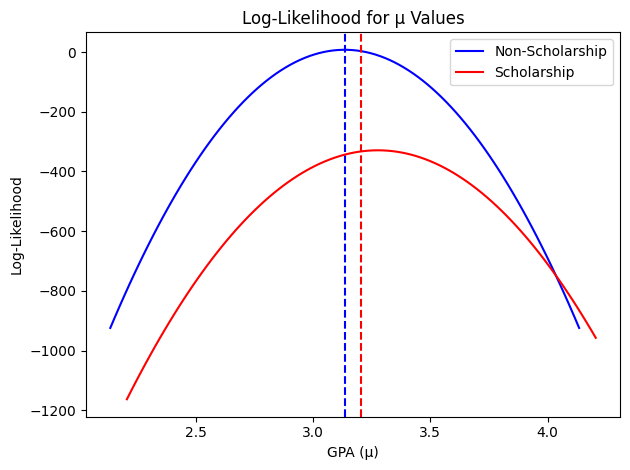

In [18]:
# Plot likelihood values

plt.figure()

plt.plot(mu_0_vals, log_likelihood_mu_0, color='Blue', label='Non-Scholarship')
plt.axvline(mu_0, linestyle='--', color='Blue')

plt.plot(mu_1_vals, log_likelihood_mu_1, color='Red', label='Scholarship')
plt.axvline(mu_1, linestyle='--', color='Red')

plt.title("Log-Likelihood for μ Values")
plt.xlabel("GPA (μ)")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation of Likelihood

In the visualization above, the log-likelihoods are plotted for the non-scholarship and scholarship groups. The curves trace the likelihood of true mean GPA for a student occurring at that GPA value, which runs along the x-axis. The likelihoods are maximized at the sample means (μ₀ and μ₁). Both curves are similar in shape, however, the non-scholarship curve has a sharper peak that also has a greater log-likelihood. This indicates the mean GPA for non-scholarship students was estimated with greater certainty.